In [7]:
import requests
import os
import datetime as dt
import json
from dotenv import load_dotenv
from google.cloud import storage
from google.cloud import bigquery 
import geopandas as gpd
import pandas as pd
import numpy as np

In [8]:
load_dotenv()

True

In [9]:
#pull a representative json from our bucket to inspect
bucket_name = os.environ.get("GCS_BUCKET_NAME")
service_acct = os.environ.get("GCS_BUCKET_CREDENTIALS")

GSclient = storage.Client.from_service_account_json(service_acct)
bucket = GSclient.bucket(bucket_name)

In [10]:
query_date = '2026-06-09'
blob = bucket.blob(f'{query_date}_311_api_call')
json_string = blob.download_as_text()
june09 = json.loads(json_string)

Regional Access Boundary HTTP request failed after retries: response_data={'error': {'code': 400, 'message': 'Precondition check failed.', 'status': 'FAILED_PRECONDITION'}}, retryable_error=False


In [11]:
june09

[{'service_request_id': '101004214056',
  'requested_datetime': '2026-06-08T19:11:11.000',
  'updated_datetime': '2026-06-09T00:52:18.000',
  'status_description': 'Open',
  'status_notes': 'in progress',
  'agency_responsible': 'PW - Street and Environmental Services',
  'service_name': 'Street and Sidewalk Cleaning',
  'service_subtype': 'garbage_and_debris',
  'service_details': 'human_waste_or_urine',
  'address': '302 12TH ST, SAN FRANCISCO, CA 94103',
  'street': '12TH ST',
  'supervisor_district': '6.0',
  'neighborhoods_sffind_boundaries': 'South of Market',
  'analysis_neighborhood': 'Mission',
  'police_district': 'SOUTHERN',
  'lat': '37.77079234085467',
  'long': '-122.41498643374592',
  'point': {'latitude': '37.77079234085467',
   'longitude': '-122.41498643374592',
   'human_address': '{"address": "", "city": "", "state": "", "zip": ""}'},
  'point_geom': {'type': 'Point',
   'coordinates': [-122.414986434, 37.770792341]},
  'source': 'Mobile',
  'media_url': {'url': 'ht

In [12]:
#see if the geometry can load in right (thus gdf ATTEMPT)
gdf_attempt = gpd.GeoDataFrame(june09)
print(gdf_attempt.head())
#gdf_attempt.plot() #lol it does not, that's okay we move on

  service_request_id       requested_datetime         updated_datetime  \
0       101004214056  2026-06-08T19:11:11.000  2026-06-09T00:52:18.000   
1       101004214794  2026-06-09T00:22:00.000  2026-06-09T01:04:59.000   
2       101004214762  2026-06-08T23:37:47.000  2026-06-09T01:23:33.000   
3       101000858880  2024-10-14T10:01:48.000  2026-06-09T01:37:18.000   
4       101003520129  2026-02-18T10:20:05.000  2026-06-09T01:37:21.000   

  status_description                                       status_notes  \
0               Open                                        in progress   
1             Closed  Case Resolved - Officer responded to request u...   
2             Closed  Case Resolved - Officer responded to request u...   
3               Open                                           accepted   
4               Open                                           accepted   

                       agency_responsible                  service_name  \
0  PW - Street and Environmen

In [13]:
#inspect columns
for c in gdf_attempt.columns:
    print(c)

service_request_id
requested_datetime
updated_datetime
status_description
status_notes
agency_responsible
service_name
service_subtype
service_details
address
street
supervisor_district
neighborhoods_sffind_boundaries
analysis_neighborhood
police_district
lat
long
point
point_geom
source
media_url
data_as_of
data_loaded_at
closed_date


In [14]:
#format list of neighborhoods
neighborhoods =  gdf_attempt['neighborhoods_sffind_boundaries'].str.lower().dropna().unique()

In [15]:
#bring in our canonical neighborhoods
BQclient = bigquery.Client()
query = '''SELECT * 
           FROM `neighboorhood-nachos.neighborhood_livability_data.neighborhoods`'''
df_canonical_neighborhoods = BQclient.query(query).to_dataframe()
df_canonical_neighborhoods.head()

,id,name,geometry
0,1,Seacliff,MULTIPOLYGON (((-122.49345526799993 37.7835181...
1,2,Lake Street,MULTIPOLYGON (((-122.48715071499993 37.7837854...
2,3,Presidio National Park,MULTIPOLYGON (((-122.47758017099994 37.8109931...
3,4,Presidio Terrace,MULTIPOLYGON (((-122.47241052999993 37.7873465...
4,5,Inner Richmond,MULTIPOLYGON (((-122.47262578999994 37.7863148...


In [16]:
#format into good list
canonical_neighborhoods = df_canonical_neighborhoods['name']
canonical_neighborhoods = [x.lower() for x in canonical_neighborhoods]

#Compare the lists!
for n in neighborhoods:
    if n not in canonical_neighborhoods:
        print(n)

st. mary's park
fisherman's wharf


In [17]:
#now, what's up with that
canonical_neighborhoods

['seacliff',
 'lake street',
 'presidio national park',
 'presidio terrace',
 'inner richmond',
 'sutro heights',
 'lincoln park / ft. miley',
 'outer richmond',
 'golden gate park',
 'presidio heights',
 'laurel heights / jordan park',
 'lone mountain',
 'anza vista',
 'cow hollow',
 'union street',
 'nob hill',
 'marina',
 'telegraph hill',
 'downtown / union square',
 'tenderloin',
 'civic center',
 'hayes valley',
 'alamo square',
 'panhandle',
 'haight ashbury',
 'lower haight',
 'mint hill',
 'duboce triangle',
 'cole valley',
 'rincon hill',
 'south beach',
 'south of market',
 'showplace square',
 'mission bay',
 'yerba buena island',
 'treasure island',
 'mission dolores',
 'castro',
 'outer sunset',
 'parkside',
 'stonestown',
 'parkmerced',
 'lakeshore',
 'golden gate heights',
 'forest hill',
 'west portal',
 'clarendon heights',
 'midtown terrace',
 'laguna honda',
 'lower nob hill',
 'upper market',
 'dolores heights',
 'mission',
 'potrero hill',
 'dogpatch',
 'central w

In [18]:
# st.mary's square and fisherman's wharf exist as st. marys square and fishermans warf, rip, let's see what we wanna do about that
neighborhoods_formatted = []
for n in neighborhoods:
    neighborhoods_formatted.append(n.replace("'",""))
for n in neighborhoods_formatted:
    if n not in canonical_neighborhoods:
        print(n)

In [19]:
#test reconfiguration
df_canonical_neighborhoods['name'] = df_canonical_neighborhoods['name'].str.lower()
neighborhood_id = []
for n in gdf_attempt['neighborhoods_sffind_boundaries'].str.lower():
    if type(n) == str:
        n = n.replace("'", "")
        neighborhood_id.append(df_canonical_neighborhoods.set_index('name').loc[n, 'id'])
    else:
        neighborhood_id.append(np.nan)

In [20]:
for id in neighborhood_id:
    if id == np.nan:
        print(id)

In [21]:
#check lengths for sanity
print(len(neighborhood_id))
print(len(gdf_attempt['neighborhoods_sffind_boundaries']))

7941
7941


In [22]:
#looks good so let's add it to the dataframe
gdf_attempt['neighborhood_id'] = neighborhood_id

<Axes: >

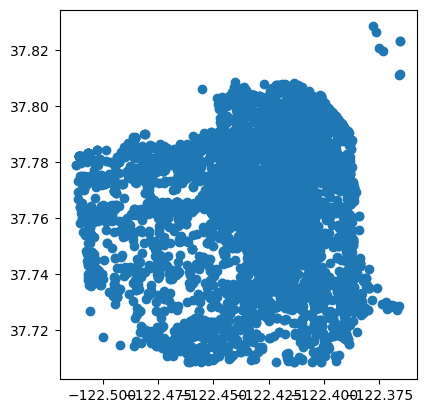

In [23]:
# fix geometry and test
gdf = gpd.GeoDataFrame(gdf_attempt, geometry=gpd.points_from_xy(gdf_attempt['long'], gdf_attempt['lat']), crs='EPSG:4326')
gdf.plot()

In [24]:
#check in on the current columns, add some of the formats I know we'll need
for c in gdf.columns:
    print(c)
gdf ['closed_datetime'] = gdf['closed_date'].copy()
gdf ['311_incident_id'] = gdf['service_request_id'].copy()

service_request_id
requested_datetime
updated_datetime
status_description
status_notes
agency_responsible
service_name
service_subtype
service_details
address
street
supervisor_district
neighborhoods_sffind_boundaries
analysis_neighborhood
police_district
lat
long
point
point_geom
source
media_url
data_as_of
data_loaded_at
closed_date
neighborhood_id
geometry


In [25]:
gdf_needed_cols = ['311_incident_id', 'neighborhood_id', 'police_district_id', 'requested_datetime',
                   'updated_datetime', 'closed_datetime', 'status_description', 'status_notes',
                   'agency_responsible', 'service_name', 'service_subtype', 'service_details', 'supervisor_district',
                   'lat', 'long', 'geometry', 'source', 'media_url']

In [26]:
#time to do the same thing for pds
query = '''SELECT * 
           FROM `neighboorhood-nachos.neighborhood_livability_data.police_districts`'''
df_canonical_pds = BQclient.query(query).to_dataframe()
df_canonical_pds.head()

,id,name,geometry
0,5,Tenderloin,MULTIPOLYGON (((-122.40217133081705 37.7862601...
1,4,Northern,MULTIPOLYGON (((-122.43379217152915 37.8079301...
2,1,Southern,MULTIPOLYGON (((-122.39186138812263 37.7942468...
3,3,Mission,MULTIPOLYGON (((-122.40953917435229 37.7693177...
4,7,Park,MULTIPOLYGON (((-122.43955630942153 37.7831382...


In [27]:
pds = gdf['police_district'].str.lower()
canonical_pds = df_canonical_pds['name']
canonical_pds = [x.lower() for x in canonical_pds]

#Compare the lists!
nan_counter = 0
for n in pds:
    if n not in canonical_pds:
        print(n)
        nan_counter += 1
print(nan_counter)


nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
88


In [28]:
gdf[gdf['police_district'].isnull()]

,service_request_id,requested_datetime,updated_datetime,status_description,status_notes,agency_responsible,service_name,service_subtype,service_details,address,...,point_geom,source,media_url,data_as_of,data_loaded_at,closed_date,neighborhood_id,geometry,closed_datetime,311_incident_id
547,101004214079,2026-06-08T19:22:01.000,2026-06-09T07:57:47.000,Closed,Accepted - DAS Intake Unit will f/u with caller.,311 - Supervisor,Service Request Copy,human_services_agency,disability_aging_services customer_callback,Not associated with a specific address,...,NaN,Phone,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-09T07:55:18.000,NaN,POINT EMPTY,2026-06-09T07:55:18.000,101004214079
643,101004189471,2026-06-04T14:00:47.000,2026-06-09T08:17:47.000,Closed,Case Resolved - Unable to properly locate City...,PW - Street and Environmental Services,General Request,public_works,dpw_other request_for_service,Not associated with a specific address,...,NaN,Twitter,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-08T09:05:42.000,NaN,POINT EMPTY,2026-06-08T09:05:42.000,101004189471
853,101004195503,2026-06-05T13:06:55.000,2026-06-09T08:56:48.000,Closed,Case Transferred - DayLighting <DayLighting@sf...,MTA - Livable Streets,General Request,municipal_transportation_agency,transportation_engineering customer_callback,Not associated with a specific address,...,NaN,Phone,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-09T08:56:48.000,NaN,POINT EMPTY,2026-06-09T08:56:48.000,101004195503
1101,101004216422,2026-06-09T09:31:26.000,2026-06-09T09:31:27.000,Open,open,Office of Cannabis,OOC Feedback,complaint,home_cultivation,Not associated with a specific address,...,NaN,Web,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,NaN,NaN,POINT EMPTY,NaN,101004216422
1144,101004197263,2026-06-05T17:20:12.000,2026-06-09T09:36:36.000,Closed,Case Resolved - Closed-Transferred to Transpor...,MTA - OPS Received (Do Not Reallocate),General Request,municipal_transportation_agency,transportation_engineering request_for_service,Not associated with a specific address,...,NaN,Web,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-09T09:30:31.000,NaN,POINT EMPTY,2026-06-09T09:30:31.000,101004197263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7621,101004226382,2026-06-10T15:27:48.000,2026-06-10T20:08:03.000,Open,open,MTA - Muni Feedback Received,Muni Employee Feedback,praise_employee,praise_employee,Not associated with a specific address,...,NaN,Phone,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,NaN,NaN,POINT EMPTY,NaN,101004226382
7622,101004227409,2026-06-10T18:01:43.000,2026-06-10T20:08:03.000,Open,open,MTA - Muni Feedback Received,Muni Employee Feedback,complaint_pass_ups_denial_inattention,bus_not_stop,Not associated with a specific address,...,NaN,Phone,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,NaN,NaN,POINT EMPTY,NaN,101004227409
7624,101004225525,2026-06-10T13:36:25.000,2026-06-10T20:08:17.000,Closed,Case Resolved - Missing or incomplete info.- n...,MTA - Muni Feedback Received,Muni Employee Feedback,complaint_pass_ups_denial_inattention,route_incomplete,Not associated with a specific address,...,NaN,Phone,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-10T20:08:17.000,NaN,POINT EMPTY,2026-06-10T20:08:17.000,101004225525
7638,101004205659,2026-06-07T13:22:11.000,2026-06-10T20:16:04.000,Closed,Case resolved,RPD - Park Service Area 1,Street and Sidewalk Cleaning,garbage_and_debris,city_garbage_can_overflowing,"100 YACHT RD, SAN FRANCISCO, CA 94110",...,"{'type': 'Point', 'coordinates': [-122.4402747...",Mobile,{'url': 'https://spot-sf-res.cloudinary.com/im...,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-10T20:16:04.000,17.0,POINT (-122.44027 37.80850),2026-06-10T20:16:04.000,101004205659


In [29]:
df_no_geom = gdf[(gdf['address'] == 'Not associated with a specific address') & (gdf['point_geom'].isna()) & (gdf['point_geom'].isna())].copy()

In [30]:
pd.set_option('display.max_rows', None)

In [31]:
df_no_geom[['status_notes', 'service_details', 'address', 'lat', 'long', 'point_geom', 'geometry', 'police_district']]

,status_notes,service_details,address,lat,long,point_geom,geometry,police_district
547,Accepted - DAS Intake Unit will f/u with caller.,disability_aging_services customer_callback,Not associated with a specific address,NaN,NaN,NaN,POINT EMPTY,NaN
643,Case Resolved - Unable to properly locate City...,dpw_other request_for_service,Not associated with a specific address,NaN,NaN,NaN,POINT EMPTY,NaN
853,Case Transferred - DayLighting <DayLighting@sf...,transportation_engineering customer_callback,Not associated with a specific address,NaN,NaN,NaN,POINT EMPTY,NaN
1101,open,home_cultivation,Not associated with a specific address,NaN,NaN,NaN,POINT EMPTY,NaN
1144,Case Resolved - Closed-Transferred to Transpor...,transportation_engineering request_for_service,Not associated with a specific address,NaN,NaN,NaN,POINT EMPTY,NaN
1667,Case Resolved - Pending investigation.,overcharging,Not associated with a specific address,NaN,NaN,NaN,POINT EMPTY,NaN
1682,open,NaN,Not associated with a specific address,NaN,NaN,NaN,POINT EMPTY,NaN
2159,Case Resolved - Investigation completed- unabl...,praise_employee,Not associated with a specific address,NaN,NaN,NaN,POINT EMPTY,NaN
2196,open,billing customer_callback,Not associated with a specific address,NaN,NaN,NaN,POINT EMPTY,NaN
2339,Case Resolved - Investigation completed,discourteous_rude,Not associated with a specific address,NaN,NaN,NaN,POINT EMPTY,NaN


In [32]:
df_no_geom['service_details'].value_counts()

service_details
comment_question_suggestion_service               5
praise_employee                                   5
discourteous_rude                                 5
transportation_engineering request_for_service    3
other_misc_feedback_requests                      3
collision_crash_damage_property                   2
verbal_physical_disagreement                      2
adopt_a_street                                    2
transportation_engineering other                  2
mta_other request_for_service                     2
overcrowding                                      2
no_show                                           2
schedule_not_followed                             2
injury_property_damage                            2
overcharging                                      2
accomodate_terminal                               1
puco request_for_service                          1
vehicle_maintenance_noise                         1
mta_other customer_callback                     

In [33]:
mask = (gdf['geometry'].is_empty) & (gdf['address'] != 'Not associated with a specific address')

In [34]:
if mask.any():
    geocodes = gpd.tools.geocode(gdf.loc[mask, 'address'], provider='arcgis')
    gdf.loc[mask, 'geometry'] = geocodes['geometry']

In [35]:
gdf[gdf['police_district'].isna() & ~gdf['geometry'].is_empty]

,service_request_id,requested_datetime,updated_datetime,status_description,status_notes,agency_responsible,service_name,service_subtype,service_details,address,...,point_geom,source,media_url,data_as_of,data_loaded_at,closed_date,neighborhood_id,geometry,closed_datetime,311_incident_id
2897,101003998241,2026-05-05T12:36:26.000,2026-06-09T16:10:22.000,Closed,Case Resolved - Called them back to give more ...,MTA - Livable Streets,General Request,municipal_transportation_agency,livable_streets request_for_service,"INTERSECTION 4TH ST, CHANNEL, SAN FRANCISCO, C...",...,NaN,Phone,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-09T16:10:22.000,NaN,POINT (-122.38969 37.77293),2026-06-09T16:10:22.000,101003998241
2910,101004044689,2026-05-12T15:34:46.000,2026-06-09T16:14:26.000,Closed,Case Resolved - Inspected -repaired,MTA - Muni Feedback Received,Street and Sidewalk Cleaning,garbage_and_debris,other_loose_garbage_debris_yard_waste,Not associated with a specific address,...,"{'type': 'Point', 'coordinates': [-122.3889814...",Web,{'url': 'https://sanfrancisco.form.us.empro.ve...,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-09T16:14:26.000,34.0,POINT (-122.38898 37.78050),2026-06-09T16:14:26.000,101004044689
4562,101004221467,2026-06-09T21:50:22.000,2026-06-10T08:39:43.000,Closed,DPT Abandoned Vehicles - No Me - FEDERAL PROPE...,MTA - Abandoned Vehicles Work,Parking Enforcement,abandoned_vehicle,NaN,"1713 BROOKS ST, SAN FRANCISCO, CA 94129",...,"{'type': 'Point', 'coordinates': [-122.4809013...",Mobile,{'url': 'https://spot-sf-res.cloudinary.com/im...,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-10T08:39:43.000,3.0,POINT (-122.48090 37.79017),2026-06-10T08:39:43.000,101004221467
4565,101004221497,2026-06-09T22:06:43.000,2026-06-10T08:40:48.000,Closed,DPT Abandoned Vehicles - No Me - FEDERAL PROPE...,MTA - Abandoned Vehicles Work,Parking Enforcement,abandoned_vehicle,NaN,"1713 BROOKS ST, SAN FRANCISCO, CA 94129",...,"{'type': 'Point', 'coordinates': [-122.4810693...",Mobile,{'url': 'https://spot-sf-res.cloudinary.com/im...,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-10T08:40:48.000,3.0,POINT (-122.48107 37.78990),2026-06-10T08:40:48.000,101004221497
4592,101004221468,2026-06-09T21:52:02.000,2026-06-10T08:44:35.000,Closed,DPT Abandoned Vehicles - No Me - FEDERAL PROPE...,MTA - Abandoned Vehicles Work,Parking Enforcement,abandoned_vehicle,NaN,"1713 BROOKS ST, SAN FRANCISCO, CA 94129",...,"{'type': 'Point', 'coordinates': [-122.4809010...",Mobile,{'url': 'https://spot-sf-res.cloudinary.com/im...,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-10T08:44:35.000,3.0,POINT (-122.48090 37.79017),2026-06-10T08:44:35.000,101004221468
5870,101004216384,2026-06-09T09:28:47.000,2026-06-10T12:40:24.000,Open,open,MTA - OPS Received (Do Not Reallocate),General Request,municipal_transportation_agency,transportation_engineering request_for_service,"INTERSECTION PIOCHE ST, GAMBIER ST, SAN FRANCI...",...,NaN,Phone,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,NaN,NaN,POINT (-122.42178 37.72664),NaN,101004216384
6435,101004223621,2026-06-10T10:06:08.000,2026-06-10T14:15:39.000,Closed,Case Resolved - Investigation completed,MTA - Muni Feedback Received,Muni Employee Feedback,complaint_pass_ups_denial_inattention,waiting_at_stop,"INTERSECTION 16TH ST, MISSION ST, SAN FRANCISC...",...,NaN,Phone,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-10T14:15:39.000,NaN,POINT (-122.40997 37.76564),2026-06-10T14:15:39.000,101004223621
6901,101004225904,2026-06-10T14:18:56.000,2026-06-10T16:20:37.000,Closed,Case Transferred - GOGA,311 - Supervisor,RPD General,park_services_area,trash_dumping,"INTERSECTION EAST BEACH RD, UNNAMED 188, SAN F...",...,"{'type': 'Point', 'coordinates': [-122.4548792...",Mobile,{'url': 'https://spot-sf-res.cloudinary.com/im...,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-10T16:20:37.000,3.0,POINT (-122.45488 37.80622),2026-06-10T16:20:37.000,101004225904
7031,1010

In [36]:
from shapely import wkt

In [38]:
df_canonical_pds['geometry'] = df_canonical_pds['geometry'].apply(wkt.loads)
df_canonical_pds = gpd.GeoDataFrame(df_canonical_pds, geometry='geometry', crs="EPSG:4326")

In [39]:
gdf = gdf.to_crs(df_canonical_pds.crs)

police_new_gdf = gpd.sjoin(gdf, df_canonical_pds[['name', 'geometry']], how='left', predicate='within')

In [43]:
police_new_gdf[police_new_gdf['police_district'].str.lower() != police_new_gdf['name'].str.lower()][['police_district', 'name']].count()

police_district    154
name               138
dtype: int64

<Axes: >

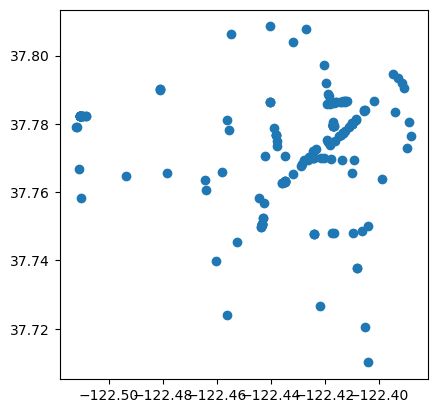

In [44]:
police_new_gdf[police_new_gdf['police_district'].str.lower() != police_new_gdf['name'].str.lower()][['police_district', 'name', 'geometry']].plot()

In [45]:
import matplotlib.pyplot as plt

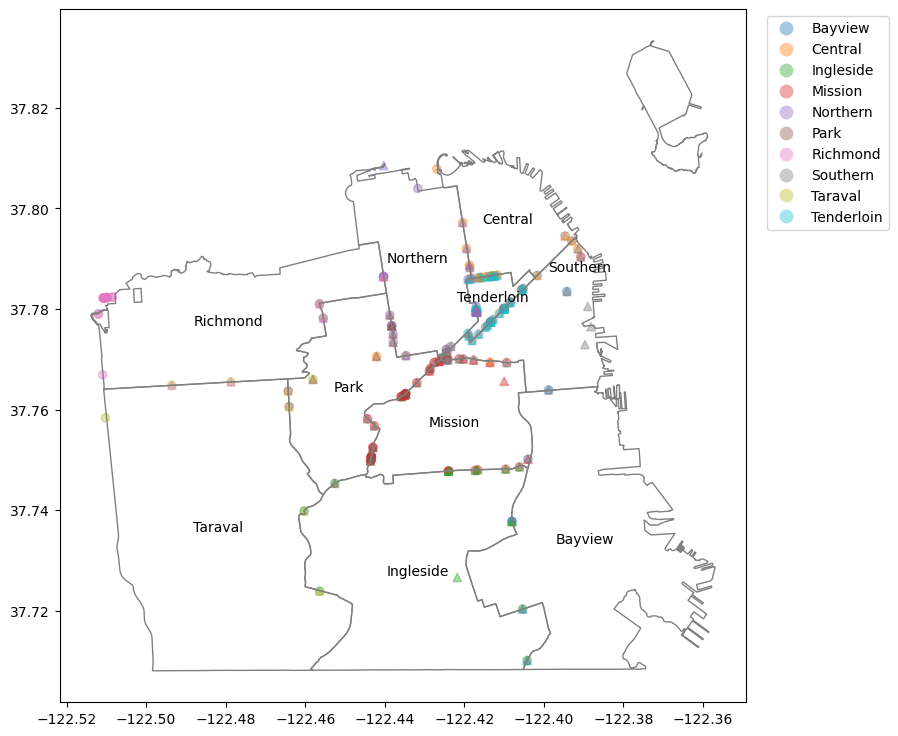

In [ ]:
fig, ax = plt.subplots(figsize=(9,9))
police_new_gdf[police_new_gdf['police_district'].str.lower() != police_new_gdf['name'].str.lower()].plot(
    'police_district', ax=ax, cmap='tab10', legend=True, alpha=.4, legend_kwds={'loc': 'upper left',
                                                                                'bbox_to_anchor': (1.02, 1)})
police_new_gdf[police_new_gdf['police_district'].str.lower() != police_new_gdf['name'].str.lower()].plot(
    'name', ax=ax, cmap='tab10', legend=True, alpha=.4, marker='^', legend_kwds={'loc': 'upper left',
                                                                                 'bbox_to_anchor': (1.02, 1)})
df_canonical_pds.plot(ax=ax, facecolor='none', edgecolor='grey')

for idx, row in df_canonical_pds.iterrows():
    centroid = row['geometry'].centroid
    label_text = str(row['name'])
    ax.text(x=centroid.x, y=centroid.y, s=label_text, 
            fontsize=10, ha='center', va='center', color='black')

In [89]:
df_canonical_neighborhoods['geometry'] = df_canonical_neighborhoods['geometry'].apply(wkt.loads)
df_canonical_neighborhoods = gpd.GeoDataFrame(df_canonical_neighborhoods, geometry='geometry', crs="EPSG:4326")

<Axes: >

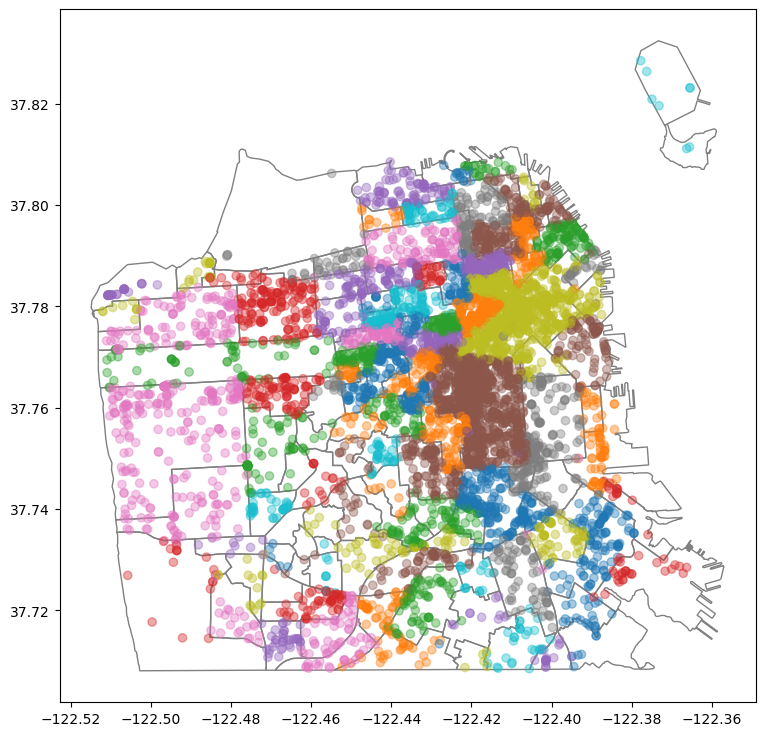

In [96]:
fig, ax = plt.subplots(figsize=(9,9))
df_canonical_neighborhoods.plot(ax=ax, facecolor='none', edgecolor='grey')
gdf.plot('neighborhoods_sffind_boundaries', ax=ax, alpha=.4, cmap='tab10')


In [97]:
gdf = gdf.to_crs(df_canonical_neighborhoods.crs)

neighborhood_new_gdf = gpd.sjoin(gdf, df_canonical_neighborhoods[['name', 'geometry']], how='left', predicate='within')
neighborhood_new_gdf[neighborhood_new_gdf['neighborhoods_sffind_boundaries'].str.lower() != neighborhood_new_gdf['name'].str.lower()][['neighborhoods_sffind_boundaries', 'name']].count()


neighborhoods_sffind_boundaries    288
name                               287
dtype: int64

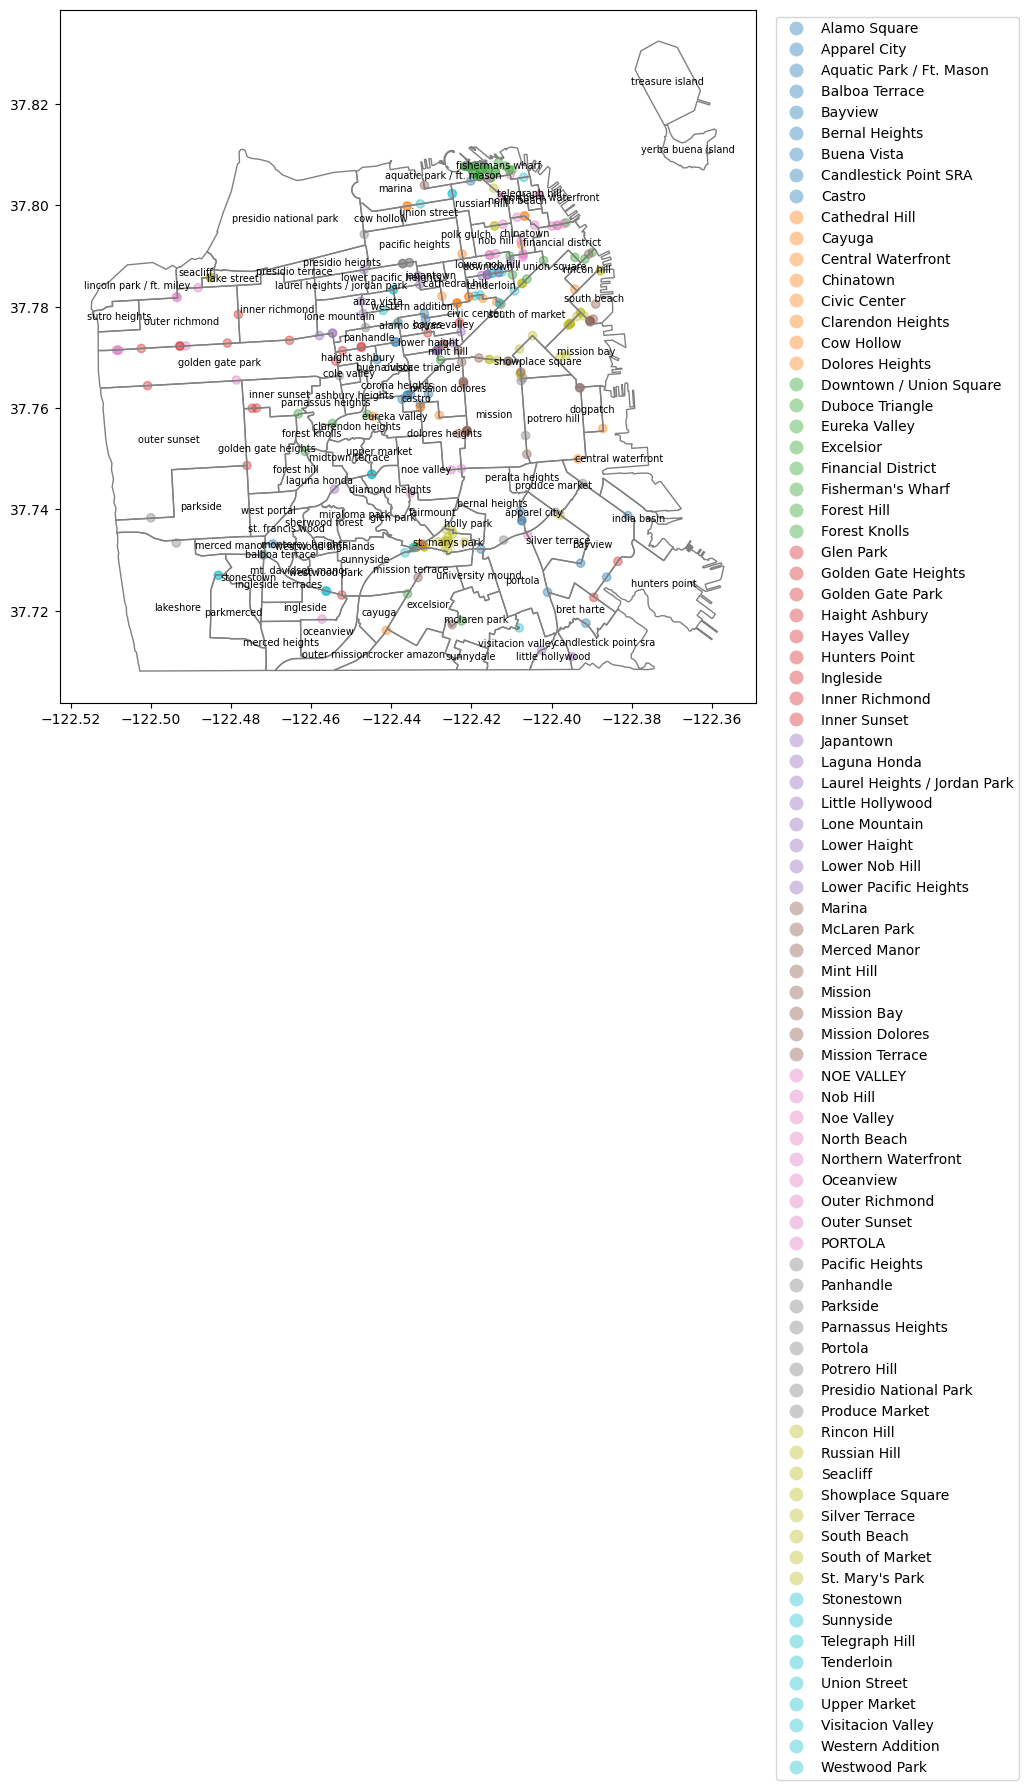

In [ ]:
fig, ax = plt.subplots(figsize=(9,9))
neighborhood_new_gdf[neighborhood_new_gdf['neighborhoods_sffind_boundaries'].str.lower() != neighborhood_new_gdf['name'].str.lower()].plot(
    'neighborhoods_sffind_boundaries', ax=ax, cmap='tab10', legend=True, alpha=.4, legend_kwds={'loc': 'upper left',
                                                                                'bbox_to_anchor': (1.02, 1)})
neighborhood_new_gdf[neighborhood_new_gdf['neighborhoods_sffind_boundaries'].str.lower() != neighborhood_new_gdf['name'].str.lower()].plot(
    'name', ax=ax, cmap='tab10', legend=True, alpha=.4, marker='^', legend_kwds={'loc': 'upper left',
                                                                                 'bbox_to_anchor': (1.02, 1)})
df_canonical_neighborhoods.plot(ax=ax, facecolor='none', edgecolor='grey')

for idx, row in df_canonical_neighborhoods.iterrows():
    centroid = row['geometry'].centroid
    label_text = str(row['name'])
    ax.text(x=centroid.x, y=centroid.y, s=label_text, 
            fontsize=7, ha='center', va='center', color='black')